In [1]:
import json
import time
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INPUT_DIR = Path("../runs/processed/sample_split")
KNN_RESULTS_DIR = Path("../runs/results/knn_baseline")
RF_RESULTS_DIR = Path("../runs/results/random_forest_sample")

RF_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input dir:", INPUT_DIR)
print("KNN results dir:", KNN_RESULTS_DIR)
print("RF results dir:", RF_RESULTS_DIR)

Input dir: ..\runs\processed\sample_split
KNN results dir: ..\runs\results\knn_baseline
RF results dir: ..\runs\results\random_forest_sample


In [2]:
#sample data load
X_train_sample = pd.read_csv(INPUT_DIR / "X_train_sample.csv")
X_val_sample = pd.read_csv(INPUT_DIR / "X_val_sample.csv")
X_test_sample = pd.read_csv(INPUT_DIR / "X_test_sample.csv")

y_train_sample = pd.read_csv(INPUT_DIR / "y_train_sample.csv").squeeze()
y_val_sample = pd.read_csv(INPUT_DIR / "y_val_sample.csv").squeeze()
y_test_sample = pd.read_csv(INPUT_DIR / "y_test_sample.csv").squeeze()

print("X_train_sample:", X_train_sample.shape)
print("X_val_sample:", X_val_sample.shape)
print("X_test_sample:", X_test_sample.shape)

print("y_train_sample:", y_train_sample.shape)
print("y_val_sample:", y_val_sample.shape)
print("y_test_sample:", y_test_sample.shape)

X_train_sample: (100000, 52)
X_val_sample: (30000, 52)
X_test_sample: (30000, 52)
y_train_sample: (100000,)
y_val_sample: (30000,)
y_test_sample: (30000,)


In [3]:
#평가함수 정의
def evaluate_binary_classification(y_true, y_pred, model_name, dataset_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    result = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision_attack": precision,
        "recall_attack": recall,
        "f1_attack": f1,
        "fpr": fpr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }
    
    return result, cm

In [4]:
#하이퍼 파라미터 
best_rf_params = {
    "n_estimators": 70,
    "max_depth": 35,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

print("Final Random Forest parameters")
print(best_rf_params)

with open(RF_RESULTS_DIR / "rf_best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_rf_params, f, indent=4, ensure_ascii=False)

print("Saved:", RF_RESULTS_DIR / "rf_best_params.json")

Final Random Forest parameters
{'n_estimators': 70, 'max_depth': 35, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Saved: ..\runs\results\random_forest_sample\rf_best_params.json


In [5]:
#학습
rf_model = RandomForestClassifier(**best_rf_params)

start_time = time.time()

rf_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time

print("Random Forest training completed.")
print("Training time(sec):", round(train_time, 4))

Random Forest training completed.
Training time(sec): 1.8832


In [6]:
#validation 성능확인
y_val_pred_rf = rf_model.predict(X_val_sample)

rf_val_result, rf_val_cm = evaluate_binary_classification(
    y_true=y_val_sample,
    y_pred=y_val_pred_rf,
    model_name="Random Forest",
    dataset_name="validation_sample"
)

rf_val_results = pd.DataFrame([rf_val_result])

display(rf_val_results)

print("Validation Confusion Matrix")
print(rf_val_cm)

,model,dataset,accuracy,precision_attack,recall_attack,f1_attack,fpr,tn,fp,fn,tp
0,Random Forest,validation_sample,0.9985,0.996637,0.994473,0.995554,0.000682,24917,17,28,5038


Validation Confusion Matrix
[[24917    17]
 [   28  5038]]


In [7]:
#test sample 평가
start_time = time.time()

y_test_pred_rf = rf_model.predict(X_test_sample)

test_inference_time = time.time() - start_time

rf_test_result, rf_test_cm = evaluate_binary_classification(
    y_true=y_test_sample,
    y_pred=y_test_pred_rf,
    model_name="Random Forest",
    dataset_name="test_sample"
)

rf_test_result["train_time_sec"] = train_time
rf_test_result["test_inference_time_sec"] = test_inference_time

rf_test_results = pd.DataFrame([rf_test_result])

print("\nClassification Report")
print(classification_report(
    y_test_sample,
    y_test_pred_rf,
    target_names=["Normal Traffic", "Attack Traffic"],
    digits=4,
    zero_division=0
))


Classification Report
                precision    recall  f1-score   support

Normal Traffic     0.9993    0.9990    0.9992     24934
Attack Traffic     0.9953    0.9964    0.9959      5066

      accuracy                         0.9986     30000
     macro avg     0.9973    0.9977    0.9975     30000
  weighted avg     0.9986    0.9986    0.9986     30000



In [8]:
#결과 표
rf_test_table = rf_test_results.copy()

rf_test_table = rf_test_table[[
    "model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

rf_test_table.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

styled_rf_test_table = (
    rf_test_table.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

display(styled_rf_test_table)

,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,Random Forest,0.9986,0.9953,0.9964,0.9959,0.0010,24,18


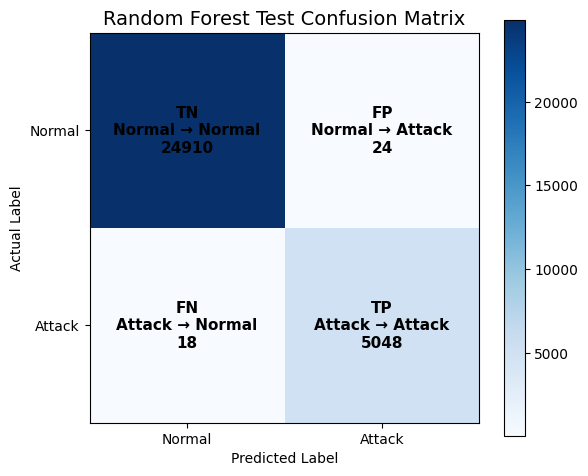

Saved: ..\runs\results\random_forest_sample\rf_test_confusion_matrix.png


In [9]:
#confusion matrix 시각화
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(rf_test_cm, cmap="Blues")

ax.set_title("Random Forest Test Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticklabels(["Normal", "Attack"])

labels = [
    ["TN\nNormal → Normal", "FP\nNormal → Attack"],
    ["FN\nAttack → Normal", "TP\nAttack → Attack"]
]

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{labels[i][j]}\n{rf_test_cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(RF_RESULTS_DIR / "rf_test_confusion_matrix.png", dpi=300)
plt.show()

print("Saved:", RF_RESULTS_DIR / "rf_test_confusion_matrix.png")

In [10]:
#결과 저장
rf_val_results.to_csv(
    RF_RESULTS_DIR / "rf_validation_results_final.csv",
    index=False
)

rf_test_results.to_csv(
    RF_RESULTS_DIR / "rf_test_results.csv",
    index=False
)

pd.DataFrame({
    "y_true": y_test_sample,
    "y_pred": y_test_pred_rf
}).to_csv(
    RF_RESULTS_DIR / "rf_test_predictions.csv",
    index=False
)

pd.DataFrame(
    rf_test_cm,
    index=["Actual_Normal_0", "Actual_Attack_1"],
    columns=["Pred_Normal_0", "Pred_Attack_1"]
).to_csv(
    RF_RESULTS_DIR / "rf_test_confusion_matrix.csv",
    index=True
)

rf_summary = {
    "model": "Random Forest",
    "data_source": "sample data generated by 00_eda.ipynb",
    "train_sample": "X_train_sample.csv, y_train_sample.csv",
    "validation_sample": "X_val_sample.csv, y_val_sample.csv",
    "test_sample": "X_test_sample.csv, y_test_sample.csv",
    "best_params": best_rf_params,
    "validation_result": rf_val_result,
    "test_result": rf_test_result
}

with open(RF_RESULTS_DIR / "rf_sample_summary.json", "w", encoding="utf-8") as f:
    json.dump(rf_summary, f, indent=4, ensure_ascii=False)

print("Saved RF final results.")

Saved RF final results.


In [11]:
#knn baseline 결과 불러오기
knn_test_results = pd.read_csv(KNN_RESULTS_DIR / "knn_test_results.csv")

knn_compare = knn_test_results.copy()

knn_compare["model"] = (
    knn_compare["model"]
    .str.replace("KNN_k", "KNN (k=", regex=False)
    + ")"
)

knn_compare = knn_compare[[
    "model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

knn_compare.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

In [12]:
#결과 비교용 
rf_compare = rf_test_results.copy()

rf_compare = rf_compare[[
    "model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

rf_compare.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

In [13]:
#knn vs random forest 표
model_comparison = pd.concat(
    [knn_compare, rf_compare],
    ignore_index=True
)

styled_model_comparison = (
    model_comparison.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

display(styled_model_comparison)

model_comparison.to_csv(
    RF_RESULTS_DIR / "knn_vs_rf_sample_comparison.csv",
    index=False
)

print("Saved:", RF_RESULTS_DIR / "knn_vs_rf_sample_comparison.csv")

,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,KNN (k=3),0.9858,0.9512,0.9657,0.9584,0.0101,251,174
1,Random Forest,0.9986,0.9953,0.9964,0.9959,0.0010,24,18


Saved: ..\runs\results\random_forest_sample\knn_vs_rf_sample_comparison.csv


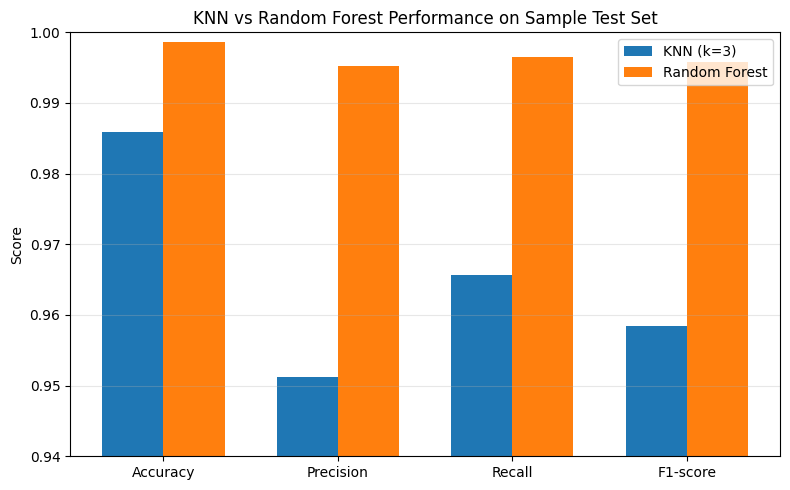

Saved: ..\runs\results\random_forest_sample\knn_vs_rf_sample_metrics.png


In [14]:
#knn vs random forest 그래프
plot_df = model_comparison.copy()

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = range(len(metrics))
bar_width = 0.35

knn_values = plot_df.iloc[0][metrics].values
rf_values = plot_df.iloc[1][metrics].values

plt.figure(figsize=(8, 5))

plt.bar(
    [i - bar_width / 2 for i in x],
    knn_values,
    width=bar_width,
    label=plot_df.iloc[0]["Model"]
)

plt.bar(
    [i + bar_width / 2 for i in x],
    rf_values,
    width=bar_width,
    label=plot_df.iloc[1]["Model"]
)

plt.xticks(list(x), metrics)
plt.ylim(0.94, 1.00)

plt.ylabel("Score")
plt.title("KNN vs Random Forest Performance on Sample Test Set")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(RF_RESULTS_DIR / "knn_vs_rf_sample_metrics.png", dpi=300)
plt.show()

print("Saved:", RF_RESULTS_DIR / "knn_vs_rf_sample_metrics.png")

In [15]:
#최종 결과 확인
saved_files = sorted([p.name for p in RF_RESULTS_DIR.iterdir()])

print("Random Forest sample experiment completed.")
print("\nSaved files:")

for file in saved_files:
    print("-", file)

Random Forest sample experiment completed.

Saved files:
- class_weight
- knn_vs_rf_sample_comparison.csv
- knn_vs_rf_sample_metrics.png
- max_depth
- min_samples_leaf
- min_samples_split
- n_estimators
- rf_best_params.json
- rf_sample_summary.json
- rf_test_confusion_matrix.csv
- rf_test_confusion_matrix.png
- rf_test_predictions.csv
- rf_test_results.csv
- rf_validation_results_final.csv
- 처음 실행 결과
